# Homelab Metrics — Exploratory Data Analysis
**Notebook 01 — EDA**

Goals:
- Load and inspect the metrics dataset
- Parse and index by timestamp
- Engineer useful derived columns
- Aggregate and resample over time
- Visualize key metrics
- Flag basic anomalies with threshold logic

## 1. Imports

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Tell matplotlib to render plots inline in the notebook
%matplotlib inline

# Widen default figure size — the default is too cramped for time series
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['figure.dpi'] = 100

## 2. Load & Inspect

`parse_dates` tells pandas to parse the timestamp column as a datetime object rather than a plain string.
Without this, time-based operations won't work — pandas would treat timestamps as opaque text.

In [24]:
df = pd.read_csv(
    '/workspace/data/metrics.csv',
    parse_dates=['timestamp']
)

print(f'Rows: {len(df)}')
print(f'Time range: {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'Duration: {df["timestamp"].max() - df["timestamp"].min()}')

Rows: 1688
Time range: 2026-05-08 14:52:30.524861 → 2026-05-09 19:27:53.435828
Duration: 1 days 04:35:22.910967


In [25]:
# Shape and column names
df.shape

(1688, 9)

In [26]:
# Data types and null counts — always run this early
# If any column shows object dtype unexpectedly, something went wrong at load time
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1688 entries, 0 to 1687
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         1688 non-null   datetime64[us]
 1   cpu_percent       1688 non-null   float64       
 2   mem_used_gb       1688 non-null   float64       
 3   mem_available_gb  1688 non-null   float64       
 4   disk_read_mb      1688 non-null   float64       
 5   disk_write_mb     1688 non-null   float64       
 6   gpu_util_percent  1688 non-null   int64         
 7   gpu_mem_used_gb   1688 non-null   float64       
 8   gpu_mem_total_gb  1688 non-null   float64       
dtypes: datetime64[us](1), float64(7), int64(1)
memory usage: 118.8 KB


In [27]:
# Statistical summary of all numeric columns
# Pay attention to min/max — obvious outliers show up here
df.describe()

,timestamp,cpu_percent,mem_used_gb,mem_available_gb,disk_read_mb,disk_write_mb,gpu_util_percent,gpu_mem_used_gb,gpu_mem_total_gb
count,1688,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.0
mean,2026-05-09 05:10:18.202320,2.655213,13.115853,17.379887,246184.285841,515235.506374,22.194313,2.003525,8.0
min,2026-05-08 14:52:30.524861,1.100000,10.440000,13.720000,236697.650000,495900.290000,1.000000,1.610000,8.0
25%,2026-05-08 22:01:30.611452,1.600000,11.990000,16.890000,240557.230000,503664.347500,11.000000,1.810000,8.0
50%,2026-05-09 05:10:18.227093,1.800000,12.740000,17.755000,250130.610000,516631.570000,25.000000,2.080000,8.0
75%,2026-05-09 12:19:05.823261,2.100000,13.610000,18.510000,250787.260000,525874.502500,27.000000,2.100000,8.0
max,2026-05-09 19:27:53.435828,62.000000,16.780000,20.050000,251558.030000,535672.000000,100.000000,7.410000,8.0
std,NaN,2.574677,1.474107,1.474078,5599.803280,12401.676168,14.197695,0.293393,0.0


In [28]:
df.head()

,timestamp,cpu_percent,mem_used_gb,mem_available_gb,disk_read_mb,disk_write_mb,gpu_util_percent,gpu_mem_used_gb,gpu_mem_total_gb
0,2026-05-08 14:52:30.524861,2.4,10.94,19.55,236697.65,495900.29,18,1.79,8.0
1,2026-05-08 14:53:31.527647,2.3,10.90,19.60,236698.18,495910.35,5,1.84,8.0
2,2026-05-08 14:54:44.985898,2.1,11.30,19.20,236698.32,495931.30,11,1.82,8.0
3,2026-05-08 14:55:45.988675,3.6,10.90,19.60,236733.32,495954.99,23,1.82,8.0
4,2026-05-08 14:56:46.990606,4.3,11.18,19.32,236734.07,495979.92,17,1.83,8.0


## 3. Set Timestamp as Index

Setting the timestamp as the DataFrame index is the standard pandas pattern for time series data.
It unlocks time-based slicing (`df['2025-01-15']`), resampling, and rolling windows.

`inplace=True` modifies the DataFrame directly rather than returning a new one.

In [29]:
df.set_index('timestamp', inplace=True)
df.sort_index(inplace=True)  # Ensure chronological order

df.head()

,cpu_percent,mem_used_gb,mem_available_gb,disk_read_mb,disk_write_mb,gpu_util_percent,gpu_mem_used_gb,gpu_mem_total_gb
timestamp,,,,,,,,
2026-05-08 14:52:30.524861,2.4,10.94,19.55,236697.65,495900.29,18,1.79,8.0
2026-05-08 14:53:31.527647,2.3,10.90,19.60,236698.18,495910.35,5,1.84,8.0
2026-05-08 14:54:44.985898,2.1,11.30,19.20,236698.32,495931.30,11,1.82,8.0
2026-05-08 14:55:45.988675,3.6,10.90,19.60,236733.32,495954.99,23,1.82,8.0
2026-05-08 14:56:46.990606,4.3,11.18,19.32,236734.07,495979.92,17,1.83,8.0


In [30]:
# Time-based slicing — grab a specific hour of data
# Adjust the date/hour string to match your actual data range
# This is one of the main payoffs of timestamp indexing
sample_hour = df.index[0].strftime('%Y-%m-%d %H')
start = pd.Timestamp(sample_hour)
end = start + pd.Timedelta(hours=1)
df.loc[start:end].head()

,cpu_percent,mem_used_gb,mem_available_gb,disk_read_mb,disk_write_mb,gpu_util_percent,gpu_mem_used_gb,gpu_mem_total_gb
timestamp,,,,,,,,
2026-05-08 14:52:30.524861,2.4,10.94,19.55,236697.65,495900.29,18,1.79,8.0
2026-05-08 14:53:31.527647,2.3,10.90,19.60,236698.18,495910.35,5,1.84,8.0
2026-05-08 14:54:44.985898,2.1,11.30,19.20,236698.32,495931.30,11,1.82,8.0
2026-05-08 14:55:45.988675,3.6,10.90,19.60,236733.32,495954.99,23,1.82,8.0
2026-05-08 14:56:46.990606,4.3,11.18,19.32,236734.07,495979.92,17,1.83,8.0


## 4. Derived Columns

Raw collector data has two issues worth fixing:
1. Memory is reported as used/available in GB, but **utilization percentage** is more interpretable
2. Disk read/write columns are **cumulative totals** since boot — the raw values aren't useful for
   spotting activity. We want the delta (how much I/O happened in each interval).

In [31]:
# Memory utilization as a percentage of total
# total = used + available
df['mem_util_pct'] = df['mem_used_gb'] / (df['mem_used_gb'] + df['mem_available_gb']) * 100
df['mem_util_pct'] = df['mem_util_pct'].round(1)

# GPU memory utilization as a percentage
df['gpu_mem_util_pct'] = df['gpu_mem_used_gb'] / df['gpu_mem_total_gb'] * 100
df['gpu_mem_util_pct'] = df['gpu_mem_util_pct'].round(1)

# Disk I/O deltas — .diff() subtracts each row from the previous row
# First row will be NaN (no previous row to diff against) — that's expected
# Clamp negatives to 0: a negative delta means the system rebooted and counters reset
df['disk_read_delta_mb'] = df['disk_read_mb'].diff().clip(lower=0).round(2)
df['disk_write_delta_mb'] = df['disk_write_mb'].diff().clip(lower=0).round(2)

print('New columns added:')
print(df[['mem_util_pct', 'gpu_mem_util_pct', 'disk_read_delta_mb', 'disk_write_delta_mb']].head(10))

New columns added:
                            mem_util_pct  gpu_mem_util_pct  \
timestamp                                                    
2026-05-08 14:52:30.524861          35.9              22.4   
2026-05-08 14:53:31.527647          35.7              23.0   
2026-05-08 14:54:44.985898          37.0              22.8   
2026-05-08 14:55:45.988675          35.7              22.8   
2026-05-08 14:56:46.990606          36.7              22.9   
2026-05-08 14:57:47.992400          36.4              22.5   
2026-05-08 14:58:48.994318          35.3              23.8   
2026-05-08 14:59:49.996303          35.7              23.8   
2026-05-08 15:00:50.998561          36.0              22.2   
2026-05-08 15:01:52.000960          36.4              22.2   

                            disk_read_delta_mb  disk_write_delta_mb  
timestamp                                                            
2026-05-08 14:52:30.524861                 NaN                  NaN  
2026-05-08 14:53:31.527647

## 5. Resampling & Aggregation

`resample()` is pandas' time series groupby. It buckets rows into time windows and lets you
aggregate (mean, max, etc.) within each bucket.

Useful for:
- Smoothing noisy per-minute data into hourly summaries
- Spotting patterns at different time scales

In [32]:
# Hourly mean of key metrics
# '1h' is the resample frequency — try '15min', '6h', '1D' to see different granularities
hourly = df[['cpu_percent', 'mem_util_pct', 'gpu_util_percent', 'gpu_mem_util_pct']].resample('1h').mean().round(1)
hourly

,cpu_percent,mem_util_pct,gpu_util_percent,gpu_mem_util_pct
timestamp,,,,
2026-05-08 14:00:00,2.8,36.0,14.6,23.0
2026-05-08 15:00:00,2.1,36.3,14.3,22.0
2026-05-08 16:00:00,2.8,36.9,20.9,23.7
2026-05-08 17:00:00,1.4,37.3,3.4,20.9
2026-05-08 18:00:00,1.5,37.8,4.2,20.6
2026-05-08 19:00:00,1.9,39.1,11.4,21.3
2026-05-08 20:00:00,2.4,43.3,19.2,22.9
2026-05-08 21:00:00,1.6,43.6,12.4,22.6
2026-05-08 22:00:00,1.6,43.8,11.8,22.5


In [33]:
# Hourly max — peaks are often more interesting than means for resource monitoring
hourly_max = df[['cpu_percent', 'mem_util_pct', 'gpu_util_percent']].resample('1h').max()
hourly_max

,cpu_percent,mem_util_pct,gpu_util_percent
timestamp,,,
2026-05-08 14:00:00,4.3,37.0,23
2026-05-08 15:00:00,9.1,37.3,44
2026-05-08 16:00:00,7.5,38.8,74
2026-05-08 17:00:00,2.9,37.8,7
2026-05-08 18:00:00,3.0,38.3,16
2026-05-08 19:00:00,3.9,41.0,48
2026-05-08 20:00:00,5.6,44.3,57
2026-05-08 21:00:00,3.2,44.4,20
2026-05-08 22:00:00,2.9,44.1,18


In [34]:
# Rolling average — smooths out per-minute noise for visualization
# window=10 means a 10-minute rolling window (each row is 1 minute)
# min_periods=1 avoids NaN at the start of the series
df['cpu_rolling_10m'] = df['cpu_percent'].rolling(window=10, min_periods=1).mean().round(1)
df['mem_rolling_10m'] = df['mem_util_pct'].rolling(window=10, min_periods=1).mean().round(1)

## 6. Visualization

Standard matplotlib pattern: `fig, ax = plt.subplots()` gives you explicit control over the figure
and axes objects. Prefer this over `plt.plot()` directly — it scales better when you have multiple
subplots and gives you cleaner control over labels, formatting, and layout.

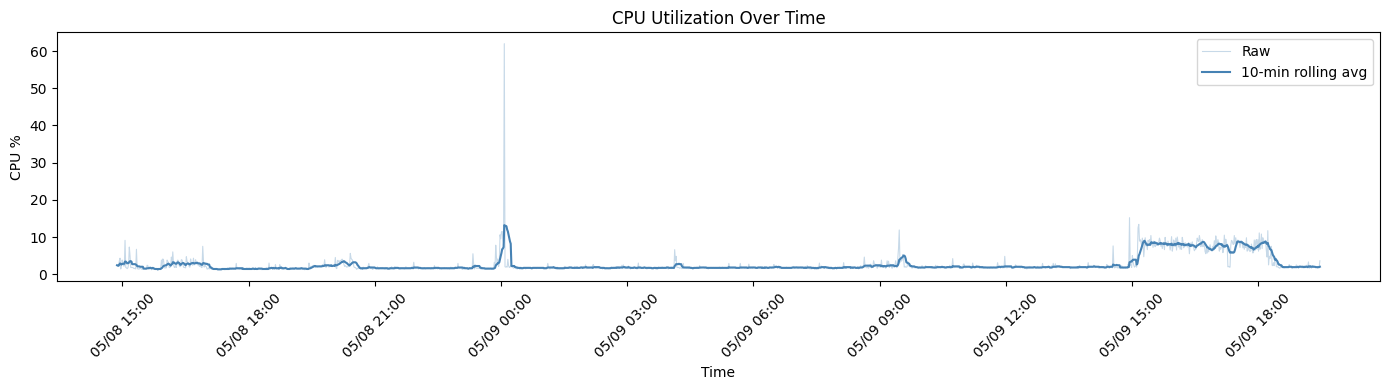

In [35]:
# CPU utilization over time — raw + rolling average
fig, ax = plt.subplots()

ax.plot(df.index, df['cpu_percent'], alpha=0.3, color='steelblue', linewidth=0.8, label='Raw')
ax.plot(df.index, df['cpu_rolling_10m'], color='steelblue', linewidth=1.5, label='10-min rolling avg')

ax.set_title('CPU Utilization Over Time')
ax.set_ylabel('CPU %')
ax.set_xlabel('Time')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

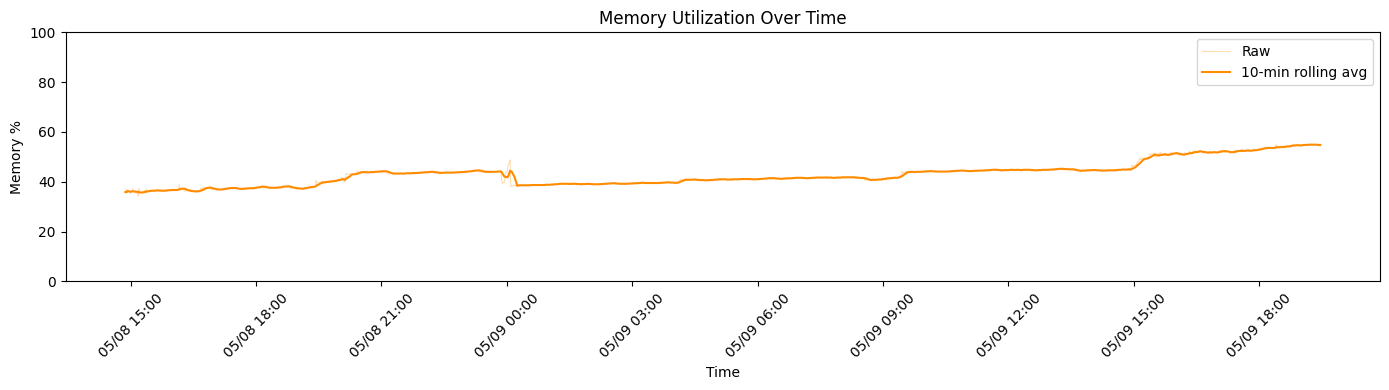

In [36]:
# Memory utilization over time
fig, ax = plt.subplots()

ax.plot(df.index, df['mem_util_pct'], alpha=0.3, color='darkorange', linewidth=0.8, label='Raw')
ax.plot(df.index, df['mem_rolling_10m'], color='darkorange', linewidth=1.5, label='10-min rolling avg')

ax.set_title('Memory Utilization Over Time')
ax.set_ylabel('Memory %')
ax.set_xlabel('Time')
ax.set_ylim(0, 100)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

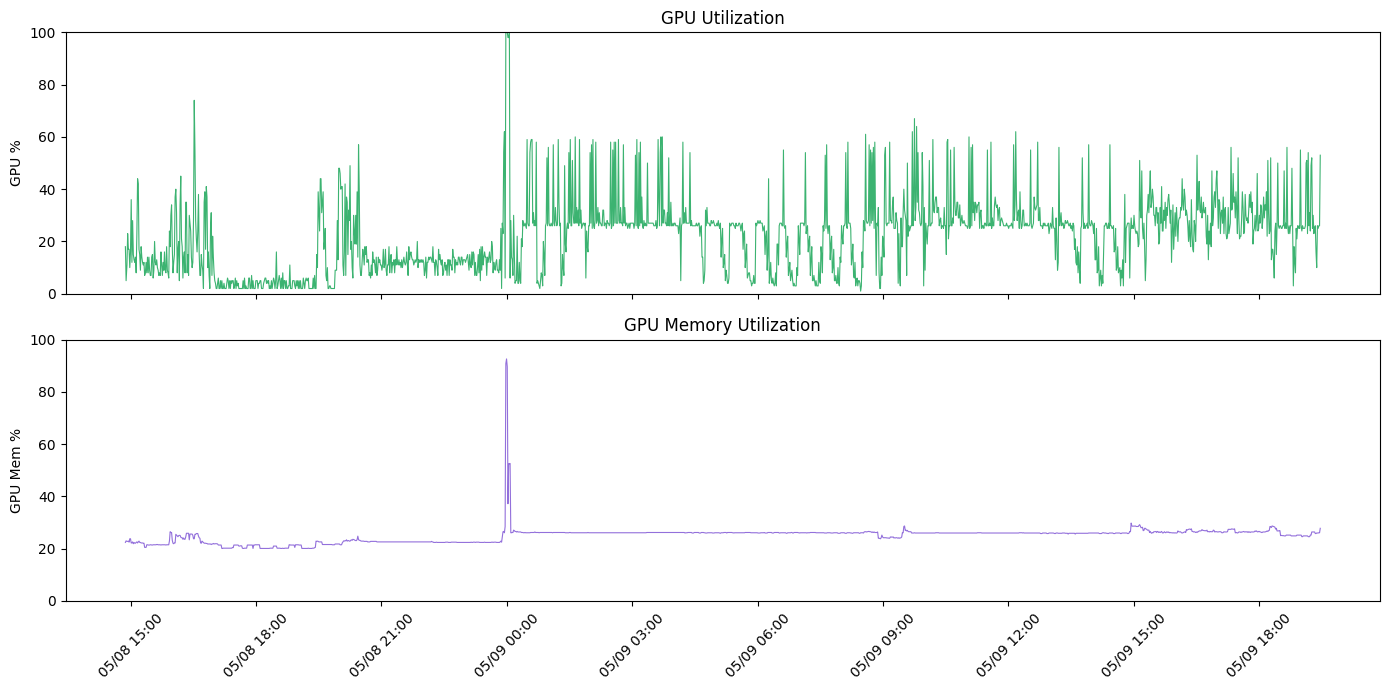

In [37]:
# GPU utilization and GPU memory — side by side subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(df.index, df['gpu_util_percent'], color='mediumseagreen', linewidth=0.8)
ax1.set_title('GPU Utilization')
ax1.set_ylabel('GPU %')
ax1.set_ylim(0, 100)

ax2.plot(df.index, df['gpu_mem_util_pct'], color='mediumpurple', linewidth=0.8)
ax2.set_title('GPU Memory Utilization')
ax2.set_ylabel('GPU Mem %')
ax2.set_ylim(0, 100)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

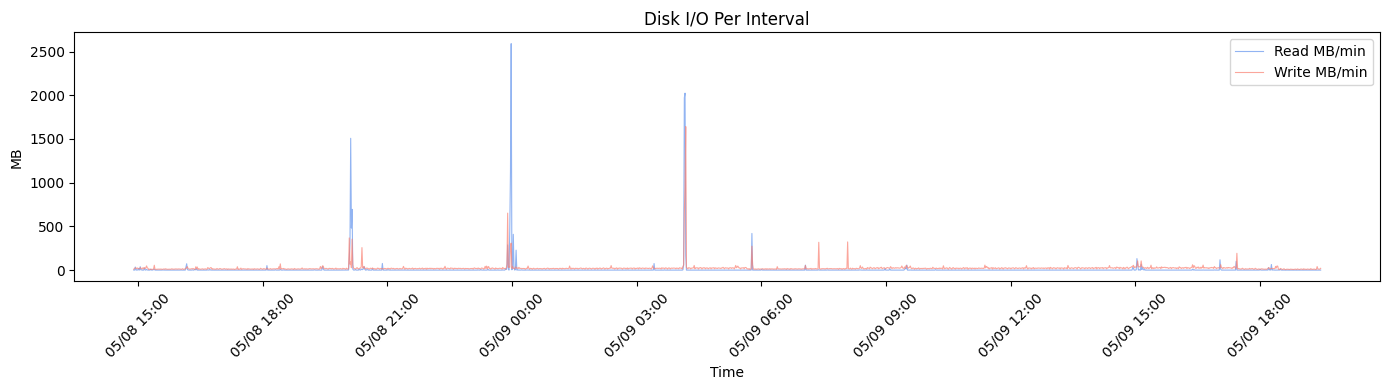

In [38]:
# Disk I/O deltas
fig, ax = plt.subplots()

ax.plot(df.index, df['disk_read_delta_mb'], color='cornflowerblue', linewidth=0.8, alpha=0.7, label='Read MB/min')
ax.plot(df.index, df['disk_write_delta_mb'], color='salmon', linewidth=0.8, alpha=0.7, label='Write MB/min')

ax.set_title('Disk I/O Per Interval')
ax.set_ylabel('MB')
ax.set_xlabel('Time')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

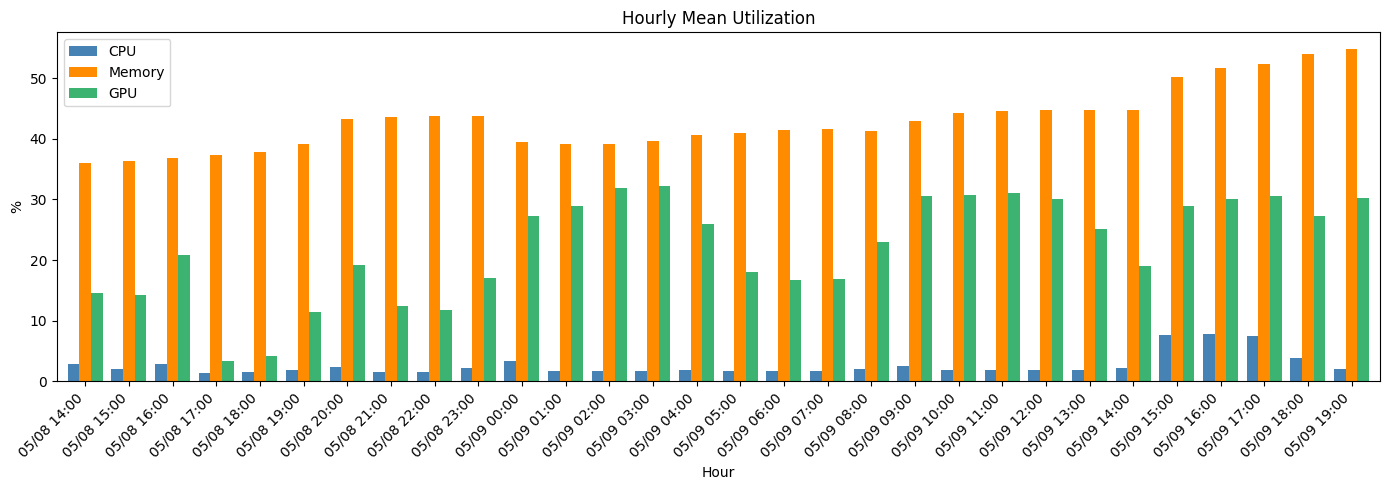

In [39]:
# Hourly mean summary — bar chart
fig, ax = plt.subplots(figsize=(14, 5))

hourly[['cpu_percent', 'mem_util_pct', 'gpu_util_percent']].plot(
    kind='bar', ax=ax, width=0.8,
    color=['steelblue', 'darkorange', 'mediumseagreen']
)

ax.set_title('Hourly Mean Utilization')
ax.set_ylabel('%')
ax.set_xlabel('Hour')
ax.legend(['CPU', 'Memory', 'GPU'])
ax.set_xticklabels([t.strftime('%m/%d %H:00') for t in hourly.index], rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Basic Anomaly Flagging

Before we get to IsolationForest, simple threshold-based flagging is worth doing first.
It's interpretable, fast, and gives you a sanity check baseline to compare against the ML approach later.

Strategy: flag any row where a metric exceeds a reasonable threshold.
We'll also use a statistical approach — flag values more than N standard deviations from the mean.

In [40]:
# Threshold-based flags
df['flag_cpu_high'] = df['cpu_percent'] > 80
df['flag_mem_high'] = df['mem_util_pct'] > 85
df['flag_gpu_high'] = df['gpu_util_percent'] > 90

print('Anomaly counts (threshold-based):')
print(f"  CPU > 80%:  {df['flag_cpu_high'].sum()} rows ({df['flag_cpu_high'].mean()*100:.1f}% of data)")
print(f"  Mem > 85%:  {df['flag_mem_high'].sum()} rows ({df['flag_mem_high'].mean()*100:.1f}% of data)")
print(f"  GPU > 90%:  {df['flag_gpu_high'].sum()} rows ({df['flag_gpu_high'].mean()*100:.1f}% of data)")

Anomaly counts (threshold-based):
  CPU > 80%:  0 rows (0.0% of data)
  Mem > 85%:  0 rows (0.0% of data)
  GPU > 90%:  6 rows (0.4% of data)


In [41]:
# Statistical anomaly flagging — Z-score approach
# Flag rows where CPU is more than 2 standard deviations above the mean
# This adapts to your actual baseline rather than using a fixed threshold
cpu_mean = df['cpu_percent'].mean()
cpu_std = df['cpu_percent'].std()

df['cpu_zscore'] = (df['cpu_percent'] - cpu_mean) / cpu_std
df['flag_cpu_zscore'] = df['cpu_zscore'] > 2

print(f'CPU mean: {cpu_mean:.1f}%  std: {cpu_std:.1f}%')
print(f'Z-score anomalies (>2σ): {df["flag_cpu_zscore"].sum()} rows')

# Show what those anomalous rows look like
df[df['flag_cpu_zscore']][['cpu_percent', 'cpu_zscore', 'mem_util_pct', 'gpu_util_percent']].head(10)

CPU mean: 2.7%  std: 2.6%
Z-score anomalies (>2σ): 110 rows


,cpu_percent,cpu_zscore,mem_util_pct,gpu_util_percent
timestamp,,,,
2026-05-08 15:03:54.004963,9.1,2.503144,36.0,15
2026-05-08 23:58:41.110116,10.6,3.085742,43.8,100
2026-05-08 23:59:42.111621,9.5,2.658504,43.9,100
2026-05-09 00:00:43.113592,11.3,3.357621,44.1,100
2026-05-09 00:01:44.115551,11.5,3.435300,46.6,98
2026-05-09 00:02:45.117540,9.5,2.658504,47.5,98
2026-05-09 00:03:46.119739,8.5,2.270105,47.5,100
2026-05-09 00:04:47.122309,62.0,23.049415,48.8,6
2026-05-09 09:28:02.231686,11.9,3.590660,44.1,18


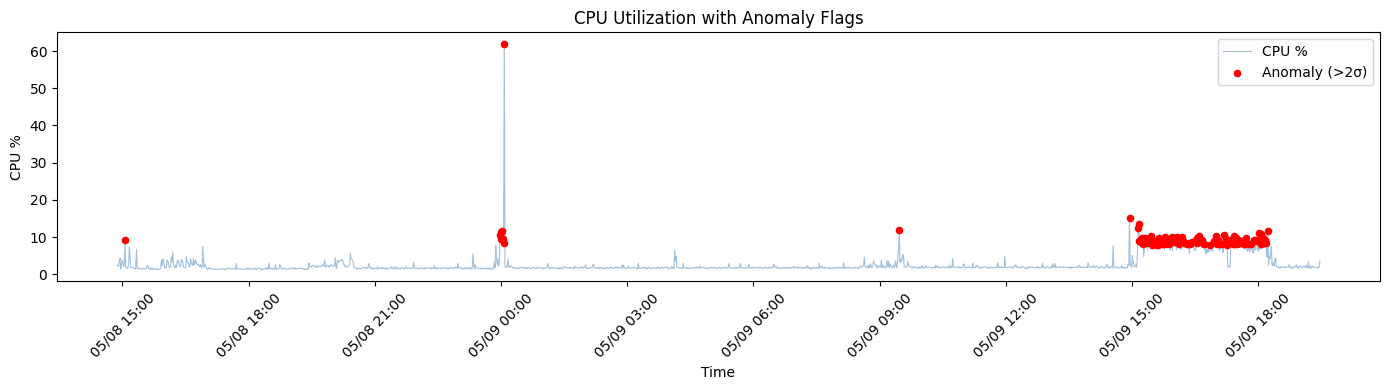

In [42]:
# Visualize CPU anomalies overlaid on the time series
fig, ax = plt.subplots()

ax.plot(df.index, df['cpu_percent'], color='steelblue', linewidth=0.8, alpha=0.5, label='CPU %')

# Scatter plot the anomalous points in red on top
anomalies = df[df['flag_cpu_zscore']]
ax.scatter(anomalies.index, anomalies['cpu_percent'], color='red', s=20, zorder=5, label='Anomaly (>2σ)')

ax.set_title('CPU Utilization with Anomaly Flags')
ax.set_ylabel('CPU %')
ax.set_xlabel('Time')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Summary Stats

Quick reference for what we observed in this dataset.

In [43]:
summary_cols = ['cpu_percent', 'mem_util_pct', 'gpu_util_percent', 'gpu_mem_util_pct',
                'disk_read_delta_mb', 'disk_write_delta_mb']

df[summary_cols].describe().round(2)

,cpu_percent,mem_util_pct,gpu_util_percent,gpu_mem_util_pct,disk_read_delta_mb,disk_write_delta_mb
count,1688.00,1688.00,1688.00,1688.00,1687.00,1687.00
mean,2.66,43.01,22.19,25.03,8.81,23.58
std,2.57,4.83,14.20,3.67,108.24,55.21
min,1.10,34.20,1.00,20.10,0.00,5.14
25%,1.60,39.30,11.00,22.60,0.00,13.74
50%,1.80,41.80,25.00,26.00,0.01,18.64
75%,2.10,44.60,27.00,26.20,0.05,23.79
max,62.00,55.00,100.00,92.60,2590.09,1641.19


In [44]:
print('=== Dataset Summary ===')
print(f"Total records:     {len(df)}")
print(f"Time span:         {df.index.max() - df.index.min()}")
print(f"CPU avg/max:       {df['cpu_percent'].mean():.1f}% / {df['cpu_percent'].max():.1f}%")
print(f"Memory avg/max:    {df['mem_util_pct'].mean():.1f}% / {df['mem_util_pct'].max():.1f}%")
print(f"GPU avg/max:       {df['gpu_util_percent'].mean():.1f}% / {df['gpu_util_percent'].max():.1f}%")
print(f"GPU mem avg/max:   {df['gpu_mem_util_pct'].mean():.1f}% / {df['gpu_mem_util_pct'].max():.1f}%")
print(f"\nAnomaly flags:")
print(f"  CPU high (>80%): {df['flag_cpu_high'].sum()}")
print(f"  Mem high (>85%): {df['flag_mem_high'].sum()}")
print(f"  GPU high (>90%): {df['flag_gpu_high'].sum()}")
print(f"  CPU z-score >2σ: {df['flag_cpu_zscore'].sum()}")

=== Dataset Summary ===
Total records:     1688
Time span:         1 days 04:35:22.910967
CPU avg/max:       2.7% / 62.0%
Memory avg/max:    43.0% / 55.0%
GPU avg/max:       22.2% / 100.0%
GPU mem avg/max:   25.0% / 92.6%

Anomaly flags:
  CPU high (>80%): 0
  Mem high (>85%): 0
  GPU high (>90%): 6
  CPU z-score >2σ: 110


## Next Steps

- **Notebook 02:** IsolationForest anomaly detection — compare ML-based flags against the threshold/z-score approach above
- **Notebook 03 (or Streamlit):** Interactive dashboard with live-updating charts